# Locating Asian hornet nests from detections at beehives: a simulation study

This notebook simulates a network of beehives, some fitted with hornet detectors that record each hornet's
departure **heading** and **ground speed**. It infers where nests are, sends search teams to the most probable
locations, removes the nests they find, and feeds every removal back into the model. It then compares detector
coverage scenarios and ends with an **interactive timelapse map** in which you can toggle detectors on hives and
add destroyed nests by clicking.

The model follows the technical documentation *Hive-Network Nest Localization System for Vespa velutina*:
a Poisson detection-rate model per nest and hive, a von Mises bearing likelihood, a homing/foraging speed
classifier, and inference over an unknown number of nests.

**Real versus simulated data**

| Component | Source in this notebook |
| --- | --- |
| Study area and basemap | Real: Schouwen-Duiveland (Zeeland), OpenStreetMap tiles in the map |
| Public hornet records | Real when online: GBIF occurrence API (Observation.org data, aggregated to 5×5 km in the Netherlands) |
| Beehive locations | Your own `data/hives.csv` if present, otherwise simulated |
| Historic removed nests | Your own `data/removed_nests.csv` if present (shown on the map), otherwise none |
| Habitat (buildings, trees) | Simulated; replace with BGT/BAG/AHN layers from PDOK for real work |
| Nests, hornet flights, detections, searches | Simulated, with parameters from the literature (Section 1) |

Every simulated quantity is labelled as such in the plots. Running the whole notebook takes a few minutes; the
scenario study (Section 10) is the slow part and its size is set by `N_REPS`.

In [158]:
import json, math, os, time, html, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.stats import norm
from scipy.optimize import brentq

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

REPO_ROOT = Path().resolve().parent
DATA_DIR = REPO_ROOT / "data"          # optional real inputs: hives.csv, removed_nests.csv
OUT_DIR = REPO_ROOT / "docs"
OUT_DIR.mkdir(exist_ok=True)
MASTER_SEED = 20260402

## 1. Parameters

Values marked *assumption* are not in the literature and should be calibrated from confirmed nests
(Section 6 of the system documentation). The others come from:

- Lioy et al. 2021 (*Sci. Rep.*): nests 395 ± 208 m from the apiary where hornets hunted (72–786 m);
  ground speed 4.06 ± 1.34 m/s homing, 6.66 ± 2.31 m/s foraging.
- Kennedy et al. 2018 (*Commun. Biol.*): nests found up to 1.33 km from release points.
- Rojas-Nossa et al. 2022 (*Front. Insect Sci.*): bearing tolerance ±10–15°; hornets avoid baits right next
  to their nest (buffer zone).
- Franklin et al. 2017 (*Appl. Entomol. Zool.*): primary nests mostly in buildings, secondary nests mostly in
  trees; urban densities above 10 nests/km².
- Rome et al. 2015 (*J. Appl. Entomol.*): nest relocation documented.

In [159]:
P = dict(
    # study area: rural polder area east of Alkmaar, Noord-Holland (real coordinates)
    lat0=52.580, lat1=52.680, lon0=4.720, lon1=4.880,
    cell=150.0,                 # inference grid cell (m)
    start_date="2026-04-01",
    season_days=244,            # 1 April to 30 November
    # nests
    nest_density=0.5,           # colonies per km² founded (Keeling 2017, Franklin 2017: 0.3–1.0 for established rural NW Europe)
    found_day_max=40,           # foundation spread over April to early May (assumption)
    p_relocate=0.7,             # share of colonies moving to a secondary nest (assumption)
    reloc_day_mean=95, reloc_day_sd=15,   # early July (assumption)
    reloc_dist_median=150.0,    # primary to secondary distance, m (assumption)
    act_max_median=30.0, act_max_sigma=0.6,   # peak hive visits per day (assumption)
    act_mid=120, act_k=0.06,    # logistic growth midpoint (end July) and rate (assumption)
    act_end=225, act_decay=7.0, # colony decline from mid November (assumption)
    # foraging kernel (Lioy 2021: 395 ± 208 m)
    kernel_median=350.0, kernel_sigma=0.55,
    buffer_b=40.0,              # buffer radius around the nest, m (assumption)
    beta_away=1.0,              # foraging effort spent away from hives
    # detection and flight
    p_det=0.8,                  # detector hit rate (assumption)
    p_homing=0.5,               # share of departures that are homing flights (assumption)
    pi_dir=0.6,                 # share of homing departures that point at the nest (assumption)
    kappa0=12.0, kappa_d0=500.0,  # von Mises concentration kappa(d) = kappa0 / (1 + d / kappa_d0)
    speed_hom=(4.06, 1.34), speed_for=(6.66, 2.31),
    clutter_rate=0.3,           # false detections per detector per day (assumption)
    n_bins=24,                  # bearing bins (15 degrees)
    # inference
    window=14, em_iter=30,
    # field response
    search_start=45, search_every=7, teams=3, p_thresh=0.25,
    search_radius=150.0, nms_radius=300.0,
    p_find_primary=0.8, p_find_secondary=0.55,
    public_h_primary=0.002, public_h_secondary=0.002,
    reproduction_day=183,       # 1 October: colonies still active are assumed to release queens
    detector_share=0.5,
)

# speed classifier threshold: where the homing and foraging speed densities cross
V_STAR = brentq(lambda v: norm.pdf(v, *P["speed_hom"]) - norm.pdf(v, *P["speed_for"]),
                P["speed_hom"][0], P["speed_for"][0])
Q_HH = norm.cdf(V_STAR, *P["speed_hom"])   # homing flight classified as homing
Q_FH = norm.cdf(V_STAR, *P["speed_for"])   # foraging flight classified as homing
P["v_star"], P["q_HH"], P["q_FH"] = V_STAR, Q_HH, Q_FH
print(f"speed threshold {V_STAR:.2f} m/s; P(class H | homing) = {Q_HH:.2f}, P(class H | foraging) = {Q_FH:.2f}")

speed threshold 5.59 m/s; P(class H | homing) = 0.87, P(class H | foraging) = 0.32


## 2. Study area and grid

In [160]:
R_EARTH = 6371000.0
LATC = 0.5 * (P["lat0"] + P["lat1"])
COSLAT = math.cos(math.radians(LATC))

def ll2xy(lat, lon):
    lat, lon = np.asarray(lat, float), np.asarray(lon, float)
    return (R_EARTH * COSLAT * np.radians(lon - P["lon0"]), R_EARTH * np.radians(lat - P["lat0"]))

def xy2ll(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    return (P["lat0"] + np.degrees(y / R_EARTH), P["lon0"] + np.degrees(x / (R_EARTH * COSLAT)))

AREA_W, _ = ll2xy(P["lat0"], P["lon1"])
_, AREA_H = ll2xy(P["lat1"], P["lon0"])
NX, NY = int(AREA_W // P["cell"]), int(AREA_H // P["cell"])
GX = (np.arange(NX) + 0.5) * P["cell"]
GY = (np.arange(NY) + 0.5) * P["cell"]
CX, CY = [a.ravel() for a in np.meshgrid(GX, GY)]      # cell centres, row-major from the south-west
NCELL = CX.size
AREA_KM2 = NX * NY * P["cell"] ** 2 / 1e6
DATES = pd.date_range(P["start_date"], periods=P["season_days"], freq="D")
print(f"area {AREA_W/1000:.1f} x {AREA_H/1000:.1f} km, grid {NX} x {NY} = {NCELL} cells of {P['cell']:.0f} m")

area 10.8 x 11.1 km, grid 71 x 74 = 5254 cells of 150 m


## 3. Real data

### 3.1 Public hornet records from GBIF

The GBIF occurrence API returns validated *Vespa velutina* records. Dutch records from Observation.org are
aggregated to 5×5 km squares on GBIF, so here they serve as context and as a check on the assumed density,
not as nest locations. Exact Dutch records are available as open data from the NDFF Flora & Fauna Verkenner;
export them to `data/ndff_vespa.csv` (columns `lat, lon, date`) to use them instead.
If the API cannot be reached, the notebook continues without these records.

GBIF records around the study area: 361


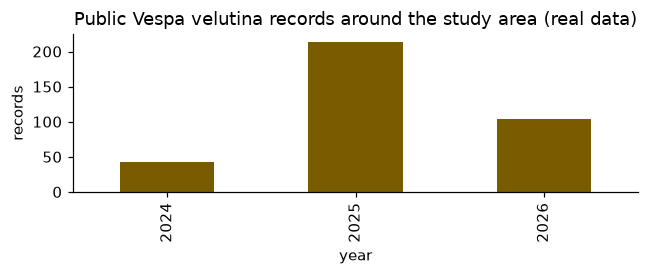

In [161]:
import requests

def fetch_gbif_vespa(lat0, lat1, lon0, lon1, pad=0.08, max_records=1500, timeout=20):
    """Return a DataFrame of GBIF Vespa velutina occurrences around the study area, or an empty frame."""
    try:
        m = requests.get("https://api.gbif.org/v1/species/match",
                         params={"name": "Vespa velutina"}, timeout=timeout).json()
        key = m["usageKey"]
        rows, offset = [], 0
        while offset < max_records:
            r = requests.get("https://api.gbif.org/v1/occurrence/search", timeout=timeout, params={
                "taxonKey": key, "hasCoordinate": "true", "limit": 300, "offset": offset,
                "decimalLatitude": f"{lat0 - pad},{lat1 + pad}",
                "decimalLongitude": f"{lon0 - pad},{lon1 + pad}"}).json()
            for o in r.get("results", []):
                rows.append(dict(lat=o.get("decimalLatitude"), lon=o.get("decimalLongitude"),
                                 year=o.get("year"), date=o.get("eventDate"),
                                 uncertainty_m=o.get("coordinateUncertaintyInMeters"),
                                 dataset=o.get("datasetName"), lifestage=o.get("lifeStage")))
            if r.get("endOfRecords", True):
                break
            offset += 300
        return pd.DataFrame(rows)
    except Exception as e:  # offline, blocked or API change
        print(f"GBIF not reachable ({type(e).__name__}); continuing without public records.")
        return pd.DataFrame(columns=["lat", "lon", "year", "date", "uncertainty_m", "dataset", "lifestage"])

ndff_csv = DATA_DIR / "ndff_vespa.csv"
if ndff_csv.exists():
    public = pd.read_csv(ndff_csv)
    public["year"] = pd.to_datetime(public["date"]).dt.year
    print(f"loaded {len(public)} NDFF records from {ndff_csv}")
else:
    public = fetch_gbif_vespa(P["lat0"], P["lat1"], P["lon0"], P["lon1"])
    print(f"GBIF records around the study area: {len(public)}")

if len(public):
    counts = public.groupby("year").size()
    ax = counts.plot(kind="bar", color="#7a5c00", figsize=(6, 2.6))
    ax.set_ylabel("records"); ax.set_title("Public Vespa velutina records around the study area (real data)")
    plt.tight_layout(); plt.show()

### 3.2 Optional local files

- `data/hives.csv` with columns `lat, lon, colonies` (and optionally `detector` as 0/1): real apiary locations
  from partner beekeepers. Without it, apiaries are simulated.
- `data/removed_nests.csv` with columns `lat, lon, date` (and optionally `type`): historic removals, for
  example from a provincial Woo request. They are drawn on the map and used to report the nearest-hive distance
  distribution, a direct check on the foraging-kernel prior.

In [162]:
hives_csv, removed_csv = DATA_DIR / "hives.csv", DATA_DIR / "removed_nests.csv"
REAL_HIVES = pd.read_csv(hives_csv) if hives_csv.exists() else None
HISTORIC = pd.read_csv(removed_csv) if removed_csv.exists() else None
print("real hive file:", "found" if REAL_HIVES is not None else "not found, hives will be simulated")
print("historic removals file:", "found" if HISTORIC is not None else "not found")

real hive file: not found, hives will be simulated
historic removals file: not found


## 4. Habitat (simulated)

Primary nests favour buildings and secondary nests favour trees (Franklin et al. 2017). Without real layers,
the notebook builds a synthetic landscape: Zierikzee's town centre at its real position, a few synthetic
hamlets, and a smooth random tree-cover field. Replace `BUILT` and `TREES` with rasterised BGT/BAG and AHN canopy
height for real use.

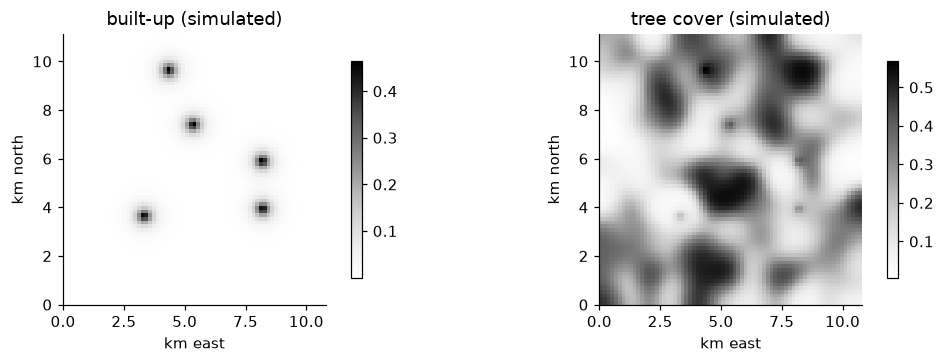

In [163]:
def make_habitat(seed):
    rng = np.random.default_rng(seed)
    tx, ty = ll2xy(51.6505, 3.9180)                      # Zierikzee centre
    hamlets = [(rng.uniform(0.1, 0.9) * AREA_W, rng.uniform(0.2, 0.95) * AREA_H) for _ in range(5)]
    d_town = np.hypot(CX - tx, CY - ty)
    built = np.exp(-d_town / 600.0)
    for hx, hy in hamlets:
        built += 0.6 * np.exp(-np.hypot(CX - hx, CY - hy) / 250.0)
    noise = ndimage.gaussian_filter(rng.normal(size=(NY, NX)), 4).ravel()
    trees = 1 / (1 + np.exp(-(noise / noise.std() * 1.2 - 0.6)))
    trees = np.clip(0.6 * trees + 0.4 * np.minimum(built, 1), 0, 1)       # gardens around houses
    built = np.clip(built, 0, 1)
    return built, trees, hamlets

BUILT, TREES, HAMLETS = make_habitat(MASTER_SEED)
SUIT_PRIMARY = 0.15 + 1.5 * BUILT + 0.3 * TREES
SUIT_SECONDARY = 0.10 + 1.2 * TREES + 0.3 * BUILT

fig, axs = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, z, t in zip(axs, [BUILT, TREES], ["built-up (simulated)", "tree cover (simulated)"]):
    im = ax.imshow(z.reshape(NY, NX), origin="lower", extent=[0, AREA_W / 1000, 0, AREA_H / 1000], cmap="Greys")
    ax.set_title(t); ax.set_xlabel("km east"); ax.set_ylabel("km north"); plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

## 5. Beehives

In [164]:
def simulate_hives(seed, n_apiaries=16):  # ~0.1 apiaries/km²; WUR: ~2.0 colonies/km² nationally, polder slightly lower
    rng = np.random.default_rng(seed)
    w = (0.2 + BUILT + 0.3 * TREES); w /= w.sum()
    idx = rng.choice(NCELL, size=n_apiaries, replace=False, p=w)
    x = CX[idx] + rng.uniform(-P["cell"] / 2, P["cell"] / 2, n_apiaries)
    y = CY[idx] + rng.uniform(-P["cell"] / 2, P["cell"] / 2, n_apiaries)
    colonies = np.clip(np.round(rng.lognormal(np.log(4), 0.7, n_apiaries)), 1, 40).astype(int)
    lat, lon = xy2ll(x, y)
    return pd.DataFrame(dict(x=x, y=y, lat=lat, lon=lon, colonies=colonies, source="simulated"))

if REAL_HIVES is not None:
    HIVES = REAL_HIVES.copy()
    HIVES["x"], HIVES["y"] = ll2xy(HIVES["lat"], HIVES["lon"])
    HIVES = HIVES[(HIVES.x >= 0) & (HIVES.x <= AREA_W) & (HIVES.y >= 0) & (HIVES.y <= AREA_H)].reset_index(drop=True)
    HIVES["source"] = "real"
else:
    HIVES = simulate_hives(MASTER_SEED + 1)
HIVES["w"] = np.sqrt(HIVES["colonies"]) / np.sqrt(HIVES["colonies"]).mean()   # attractiveness w_h
NH = len(HIVES)
HX, HY, HW = HIVES.x.values, HIVES.y.values, HIVES.w.values

rng_det = np.random.default_rng(MASTER_SEED + 2)
if "detector" in HIVES:
    DEFAULT_DETECTORS = HIVES["detector"].astype(bool).values
else:
    DEFAULT_DETECTORS = np.zeros(NH, bool)
    DEFAULT_DETECTORS[rng_det.choice(NH, int(round(P["detector_share"] * NH)), replace=False)] = True
print(f"{NH} apiaries ({HIVES.source.iloc[0]}), {DEFAULT_DETECTORS.sum()} with detectors by default")

16 apiaries (simulated), 8 with detectors by default


## 6. Hornet colonies (simulated truth)

Each colony is founded in spring at a primary nest, may relocate to a secondary nest in summer, grows
logistically and declines in late autumn. Nests can also be found and removed by the public, with a small daily
hazard that rises when leaves fall (from October); most nests in Flanders were found from mid-October to late
November (VRT, 2023).

58 colonies founded; 40 relocate


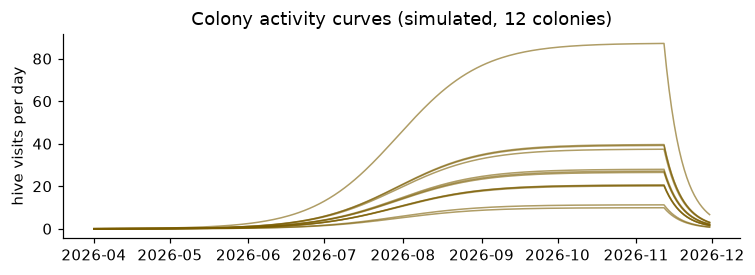

In [165]:
def activity_curve(t):
    t = np.asarray(t, float)
    g = 1 / (1 + np.exp(-P["act_k"] * (t - P["act_mid"])))
    decline = np.where(t > P["act_end"], np.exp(-(t - P["act_end"]) / P["act_decay"]), 1.0)
    return g * decline

def simulate_colonies(seed):
    rng = np.random.default_rng(seed)
    n = rng.poisson(P["nest_density"] * AREA_KM2)
    wp = SUIT_PRIMARY / SUIT_PRIMARY.sum()
    idx = rng.choice(NCELL, size=n, p=wp)
    px = np.clip(CX[idx] + rng.uniform(-75, 75, n), 1, AREA_W - 1)
    py = np.clip(CY[idx] + rng.uniform(-75, 75, n), 1, AREA_H - 1)
    found = rng.integers(0, P["found_day_max"], n)
    relocates = rng.random(n) < P["p_relocate"]
    reloc_day = np.where(relocates, np.clip(rng.normal(P["reloc_day_mean"], P["reloc_day_sd"], n), 60, 140), np.inf)
    sx, sy = px.copy(), py.copy()
    for i in np.where(relocates)[0]:                     # secondary site: nearby, weighted by tree cover
        d = rng.lognormal(np.log(P["reloc_dist_median"]), 0.7, 20)
        a = rng.uniform(0, 2 * np.pi, 20)
        cx = np.clip(px[i] + d * np.sin(a), 1, AREA_W - 1); cy = np.clip(py[i] + d * np.cos(a), 1, AREA_H - 1)
        ci = (np.minimum((cy // P["cell"]).astype(int), NY - 1) * NX + np.minimum((cx // P["cell"]).astype(int), NX - 1))
        ww = SUIT_SECONDARY[ci]; k = rng.choice(20, p=ww / ww.sum())
        sx[i], sy[i] = cx[k], cy[k]
    amax = rng.lognormal(np.log(P["act_max_median"]), P["act_max_sigma"], n)
    # public discovery days (simulated): one draw per phase
    days = np.arange(P["season_days"])
    pub_pri = np.full(n, np.inf); pub_sec = np.full(n, np.inf)
    for i in range(n):
        switch = reloc_day[i] if np.isfinite(reloc_day[i]) else P["reloc_day_mean"]
        end_pri = min(switch, P["season_days"])
        u = rng.random(P["season_days"])
        hit = np.where((days >= found[i]) & (days < end_pri) & (u < P["public_h_primary"]))[0]
        if hit.size: pub_pri[i] = hit[0]
        h = P["public_h_secondary"] * activity_curve(days) * np.where(days >= 183, 3.0, 1.0)
        start_sec = switch
        u = rng.random(P["season_days"])
        hit = np.where((days >= start_sec) & (u < h))[0]
        if hit.size: pub_sec[i] = hit[0]
    lat_p, lon_p = xy2ll(px, py); lat_s, lon_s = xy2ll(sx, sy)
    switch_day = np.where(np.isfinite(reloc_day), reloc_day, P["reloc_day_mean"])
    return pd.DataFrame(dict(px=px, py=py, sx=sx, sy=sy, found=found, reloc=reloc_day, switch=switch_day, amax=amax,
                             pub_pri=pub_pri, pub_sec=pub_sec,
                             lat_p=lat_p, lon_p=lon_p, lat_s=lat_s, lon_s=lon_s))

COL = simulate_colonies(MASTER_SEED + 3)
print(f"{len(COL)} colonies founded; {np.isfinite(COL.reloc).sum()} relocate")

t = np.arange(P["season_days"])
fig, ax = plt.subplots(figsize=(7, 2.6))
for a in COL.amax.values[:12]:
    ax.plot(DATES, a * activity_curve(t), lw=1, color="#7a5c00", alpha=0.6)
ax.set_ylabel("hive visits per day"); ax.set_title("Colony activity curves (simulated, 12 colonies)")
plt.tight_layout(); plt.show()

## 7. Observation model

Nest *j* produces detections at hive *h* as a Poisson process with rate

λ_jh(t) = a_j(t) · p_det · w_h k(d_jh) / (β + Σ_h' w_h' k(d_jh'))

The per-hive kernel is k(d) ∝ f(d)/d, where f is the lognormal fit to the nest–apiary distances of Lioy et al.
(2021). Dividing by *d* matters: those distances were measured from the apiary where hornets hunted, so they
already include the fact that more nests lie at larger distances (the ring area grows with *d*). k is multiplied
by a buffer term 1 − exp(−(d/b)²). Each detection carries a bearing bin (von Mises around the true bearing for
directed homing flights, uniform otherwise) and a speed class (homing-like or foraging-like). False detections
arrive at each detector at rate ρ with uniform bearings.

P(class H) = 0.60; P(directed | H) = 0.44, P(directed | F) = 0.09


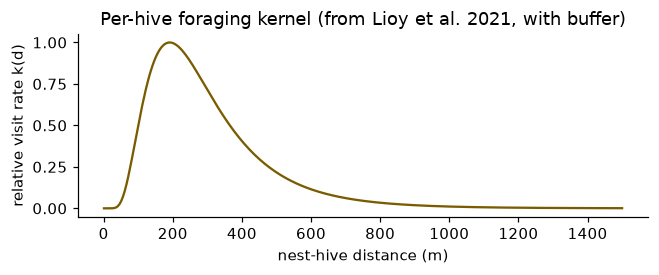

In [166]:
NB = P["n_bins"]
BIN_CENTRES = (np.arange(NB) + 0.5) * 2 * np.pi / NB
_d = np.linspace(1, 3000, 3000)
_f = norm.pdf(np.log(_d), np.log(P["kernel_median"]), P["kernel_sigma"]) / _d
_k = _f / _d * (1 - np.exp(-(_d / P["buffer_b"]) ** 2))
K_NORM = _k.max()

def kernel(d):
    d = np.maximum(np.asarray(d, float), 1.0)
    f = norm.pdf(np.log(d), np.log(P["kernel_median"]), P["kernel_sigma"]) / d
    return f / d * (1 - np.exp(-(d / P["buffer_b"]) ** 2)) / K_NORM

def site_factors(x, y):
    """For source points (n,), return K (n, NH): expected detections per unit activity, and G (n, NH, NB): bearing-bin probabilities."""
    x, y = np.atleast_1d(x).astype(float), np.atleast_1d(y).astype(float)
    dx, dy = x[:, None] - HX[None, :], y[:, None] - HY[None, :]
    d = np.hypot(dx, dy)
    kw = HW[None, :] * kernel(d)
    K = P["p_det"] * kw / (P["beta_away"] + kw.sum(1, keepdims=True))
    phi = np.arctan2(dx, dy) % (2 * np.pi)                     # compass bearing hive -> nest
    kap = P["kappa0"] / (1 + d / P["kappa_d0"])
    lg = kap[..., None] * np.cos(BIN_CENTRES[None, None, :] - phi[..., None])
    lg -= lg.max(-1, keepdims=True)
    G = np.exp(lg); G /= G.sum(-1, keepdims=True)
    return K.astype(np.float32), G.astype(np.float32)

GRID_K, GRID_G = site_factors(CX, CY)
P_H = P["p_homing"] * Q_HH + (1 - P["p_homing"]) * Q_FH              # P(class H) for a nest detection
PI_CLS = np.array([P["p_homing"] * P["pi_dir"] * Q_HH / P_H,              # P(directed | class H)
                   P["p_homing"] * P["pi_dir"] * (1 - Q_HH) / (1 - P_H)])  # P(directed | class F)
P_CLS = np.array([P_H, 1 - P_H])
CLUTTER_CLS = np.array([Q_FH, 1 - Q_FH])
print(f"P(class H) = {P_H:.2f}; P(directed | H) = {PI_CLS[0]:.2f}, P(directed | F) = {PI_CLS[1]:.2f}")

dd = np.linspace(1, 1500, 300)
fig, ax = plt.subplots(figsize=(6, 2.6))
ax.plot(dd, kernel(dd), color="#7a5c00")
ax.set_xlabel("nest-hive distance (m)"); ax.set_ylabel("relative visit rate k(d)")
ax.set_title("Per-hive foraging kernel (from Lioy et al. 2021, with buffer)")
plt.tight_layout(); plt.show()

def generate_detections(rng, lam, G):
    """lam (H,) expected detections at detector hives for one source; G (H, NB). Returns counts (H, 2, NB)."""
    out = np.zeros((lam.size, 2, NB), np.int32)
    n = rng.poisson(lam)
    for h in np.nonzero(n)[0]:
        nh = rng.binomial(n[h], P["p_homing"]); nf = n[h] - nh
        nd = rng.binomial(nh, P["pi_dir"]); nu = nh - nd
        ndH = rng.binomial(nd, Q_HH); nuH = rng.binomial(nu, Q_HH); nfH = rng.binomial(nf, Q_FH)
        g = G[h].astype(np.float64); g /= g.sum()
        out[h, 0] += rng.multinomial(ndH, g); out[h, 1] += rng.multinomial(nd - ndH, g)
        uni = np.full(NB, 1 / NB)
        out[h, 0] += rng.multinomial(nuH + nfH, uni); out[h, 1] += rng.multinomial(nu - nuH + nf - nfH, uni)
    return out

## 8. Inference

Detections in a sliding window (14 days) are explained as a superposition of sources: an unknown nest
intensity μ_c on every grid cell, known (removed) nests with their exposure before removal, and clutter. The
intensity is estimated with the EM algorithm for Poisson mixtures (maximum-likelihood expectation maximisation,
as in emission tomography), stopped after a fixed number of iterations as regularisation. This handles an unknown
number of nests without sampling (a tractable stand-in for the Dirichlet-process tier of the documentation).

The intensity is converted to expected nests per cell, λ_c = μ_c / a_ref(t), using the typical colony activity
at that time, plus a prior term for cells the detectors barely cover. The map shows the probability of at least
one active nest within the 3×3-cell block around each cell (450 m square).

In [167]:
def a_ref(t):
    return P["act_max_median"] * max(float(activity_curve(t)), 0.05)

def box3(z):
    return ndimage.uniform_filter(z.reshape(NY, NX), size=3, mode="constant").ravel() * 9

def infer(nwin, det, known, t, iters=None):
    """nwin (NH, 2, NB) window counts; det bool (NH,); known: list of (Ks (NH,), Gs (NH, NB), exposure_days).
    Returns dict with mu (cells), lam (expected nests per cell), p3 (P(nest in 3x3 block)), mu_known."""
    iters = iters or P["em_iter"]
    W = min(P["window"], t + 1)
    hs = np.nonzero(det)[0]
    lam0 = P["nest_density"] * (P["cell"] ** 2 / 1e6) * 0.5
    if hs.size == 0:
        lam = np.full(NCELL, lam0)
        return dict(mu=np.zeros(NCELL), lam=lam, p3=1 - np.exp(-box3(lam)), mu_known=np.zeros(len(known)))
    n = nwin[hs].astype(np.float64)
    K, G = GRID_K[:, hs].astype(np.float64), GRID_G[:, hs, :].astype(np.float64)
    expo = W * K.sum(1)
    clutter = P["clutter_rate"] * W * CLUTTER_CLS[None, :, None] / NB * np.ones((hs.size, 1, NB))
    S = len(known)
    if S:
        Ks = np.array([k[0][hs] for k in known], np.float64)
        Gs = np.array([k[1][hs] for k in known], np.float64)
        Es = np.array([k[2] for k in known], np.float64)
        expo_s = Es * Ks.sum(1)
    total = n.sum()
    active = expo > 1e-6
    mu = np.where(active, max(total, 1.0) / (expo.sum() + 1e-9), 0.0)
    mus = np.full(S, max(total, 1.0) / (expo.sum() + 1e-9)) if S else np.zeros(0)
    pc, pi = P_CLS[None, :, None], PI_CLS[None, :, None]
    for _ in range(iters):
        A = (mu * W)[:, None] * K                                   # (C, h)
        GA, sA = np.einsum("ch,chb->hb", A, G), A.sum(0)
        pred = clutter + pc * (pi * GA[:, None, :] + (1 - pi) * sA[:, None, None] / NB)
        if S:
            As = (mus * Es)[:, None] * Ks
            GAs, sAs = np.einsum("sh,shb->hb", As, Gs), As.sum(0)
            pred = pred + pc * (pi * GAs[:, None, :] + (1 - pi) * sAs[:, None, None] / NB)
        ratio = np.where(n > 0, n / np.maximum(pred, 1e-12), 0.0)
        rdir = (pc * pi * ratio).sum(1)                              # (h, B)
        rund = ((pc * (1 - pi) / NB) * ratio).sum((1, 2))            # (h,)
        back = W * (K * (np.einsum("chb,hb->ch", G, rdir) + rund[None, :])).sum(1)
        mu = np.where(active, mu * back / np.maximum(expo, 1e-12), 0.0)
        if S:
            back_s = Es * (Ks * (np.einsum("shb,hb->sh", Gs, rdir) + rund[None, :])).sum(1)
            mus = np.where(expo_s > 1e-9, mus * back_s / np.maximum(expo_s, 1e-12), 0.0)
    ar = a_ref(t)
    lam = mu / ar + lam0 * np.exp(-ar * expo)
    return dict(mu=mu, lam=lam, p3=1 - np.exp(-box3(lam)), mu_known=mus)

### 8.1 Sanity check: one nest, a few detectors

A single nest with fixed activity is placed among the apiaries; detections from 14 days are simulated and
inferred. The plot shows the estimated probability map and the error of the map peak as activity rises.

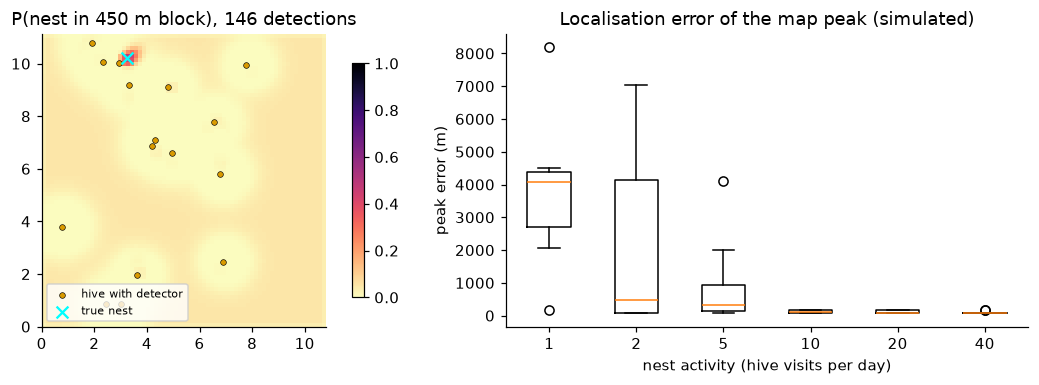

In [168]:
rng = np.random.default_rng(MASTER_SEED + 10)
# place the test nest 350 m from the apiary with the most neighbours within 1.5 km
_nb = (np.hypot(HX[:, None] - HX[None, :], HY[:, None] - HY[None, :]) < 1500).sum(1)
_h = int(np.argmax(_nb))
nest_xy = (float(np.clip(HX[_h] + 350 * np.sin(1.0), 0, AREA_W)), float(np.clip(HY[_h] + 350 * np.cos(1.0), 0, AREA_H)))
Kn, Gn = site_factors(*nest_xy)
det_all = np.ones(NH, bool)

def one_nest_trial(activity, rng, det=det_all, t=150):
    counts = np.zeros((NH, 2, NB), np.int32)
    for _ in range(P["window"]):
        counts[det] += generate_detections(rng, activity * Kn[0][det], Gn[0][det])
        clut = rng.poisson(P["clutter_rate"], det.sum())
        for k, h in enumerate(np.nonzero(det)[0]):
            if clut[k]:
                c = rng.binomial(clut[k], Q_FH)
                counts[h, 0] += rng.multinomial(c, np.full(NB, 1 / NB))
                counts[h, 1] += rng.multinomial(clut[k] - c, np.full(NB, 1 / NB))
    res = infer(counts, det, [], t)
    peak = np.argmax(res["lam"])
    return res, counts.sum(), np.hypot(CX[peak] - nest_xy[0], CY[peak] - nest_xy[1])

res, ndet, err = one_nest_trial(20.0, rng)
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
im = ax[0].imshow(res["p3"].reshape(NY, NX), origin="lower", extent=[0, AREA_W / 1000, 0, AREA_H / 1000], cmap="magma_r", vmin=0, vmax=1)
ax[0].scatter(HX / 1000, HY / 1000, s=14, c="#d99a00", edgecolor="k", lw=0.4, label="hive with detector")
ax[0].scatter([nest_xy[0] / 1000], [nest_xy[1] / 1000], marker="x", c="cyan", s=60, label="true nest")
ax[0].set_title(f"P(nest in 450 m block), {ndet} detections"); ax[0].legend(loc="lower left", fontsize=7)
plt.colorbar(im, ax=ax[0], shrink=0.8)
acts = [1, 2, 5, 10, 20, 40]
errs = [[one_nest_trial(a, rng)[2] for _ in range(8)] for a in acts]
ax[1].boxplot(errs, tick_labels=[str(a) for a in acts])
ax[1].set_xlabel("nest activity (hive visits per day)"); ax[1].set_ylabel("peak error (m)")
ax[1].set_title("Localisation error of the map peak (simulated)")
plt.tight_layout(); plt.show()

## 9. Closed-loop season

Each day: nests founded, relocated or reported by the public; detectors record flights; weekly from mid-May,
the model is refitted and up to three teams search the highest-probability areas (non-maximum suppression at
300 m, threshold 0.25). A team finds a nest within 200 m of its target with probability 0.8 for a primary nest
and 0.55 for a secondary nest high in a tree. Every removal becomes a known source; failed searches block that
area for two weeks.

In [169]:
COLONY_SITES = {}

def colony_sites(col):
    key = id(col)
    if key not in COLONY_SITES:
        Kp, Gp = site_factors(col.px.values, col.py.values)
        Ks, Gs = site_factors(col.sx.values, col.sy.values)
        COLONY_SITES[key] = (Kp, Gp, Ks, Gs)
    return COLONY_SITES[key]

def run_season(col, detectors, seed, record_every=0, search=True):
    rng = np.random.default_rng(seed)
    T, n = P["season_days"], len(col)
    Kp, Gp, Ks, Gs = colony_sites(col)
    removed = np.full(n, np.inf); removed_by = np.array([""] * n, dtype=object)
    counts = np.zeros((T, NH, 2, NB), np.int32)
    known, searches, frames = [], [], {}
    amax, found, reloc, switch = col.amax.values, col.found.values, col.reloc.values, col.switch.values
    pub_pri, pub_sec = col.pub_pri.values, col.pub_sec.values
    hs = np.nonzero(detectors)[0]
    blocked = []                                         # (x, y, until_day)

    def site(i, d):
        sec = d >= reloc[i]
        return (col.sx.values[i], col.sy.values[i], Ks[i], Gs[i]) if sec else (col.px.values[i], col.py.values[i], Kp[i], Gp[i])

    def remove(i, d, how):
        removed[i], removed_by[i] = d, how
        x, y, K_, G_ = site(i, d - 1)
        known.append(dict(colony=i, x=x, y=y, day=d, how=how, K=K_, G=G_))

    for d in range(T):
        alive = (found <= d) & (removed > d)
        for i in np.nonzero(alive)[0]:                   # public reports (removal takes effect today)
            if (d < switch[i] and d >= pub_pri[i]) or (d >= switch[i] and d >= pub_sec[i]):
                remove(i, d, "public")
        alive = (found <= d) & (removed > d)
        act = activity_curve(d)
        for i in np.nonzero(alive)[0]:
            _, _, K_, G_ = site(i, d)
            counts[d, hs] += generate_detections(rng, amax[i] * act * K_[hs], G_[hs])
        clut = rng.poisson(P["clutter_rate"], hs.size)
        for k, h in enumerate(hs):
            if clut[k]:
                c = rng.binomial(clut[k], Q_FH)
                counts[d, h, 0] += rng.multinomial(c, np.full(NB, 1 / NB))
                counts[d, h, 1] += rng.multinomial(clut[k] - c, np.full(NB, 1 / NB))
        weekly = d >= P["search_start"] and (d - P["search_start"]) % P["search_every"] == 0
        want_frame = record_every and d % record_every == 0
        if (search and weekly and hs.size) or want_frame:
            lo = max(0, d - P["window"] + 1)
            nwin = counts[lo:d + 1].sum(0)
            kn = [(k["K"][0] if k["K"].ndim > 1 else k["K"], k["G"], min(P["window"], max(0, k["day"] - lo)))
                  for k in known if k["day"] > lo]
            res = infer(nwin, detectors, kn, d)
            if want_frame:
                frames[d] = res["p3"].astype(np.float32)
            if search and weekly and hs.size:
                p3 = res["p3"].copy()
                blocked[:] = [b for b in blocked if b[2] > d]
                for bx, by, _ in blocked:
                    p3[np.hypot(CX - bx, CY - by) < P["search_radius"]] = 0
                order = np.argsort(-p3); chosen = []
                for c in order:
                    if p3[c] < P["p_thresh"] or len(chosen) >= P["teams"]:
                        break
                    if all(np.hypot(CX[c] - CX[o], CY[c] - CY[o]) >= P["nms_radius"] for o in chosen):
                        chosen.append(c)
                for c in chosen:
                    alive = (found <= d) & (removed > d)
                    cand = []
                    for i in np.nonzero(alive)[0]:
                        x, y, _, _ = site(i, d)
                        dist = math.hypot(x - CX[c], y - CY[c])
                        if dist <= 200.0:
                            cand.append((dist, i))
                    ok = False
                    if cand:
                        dist, i = min(cand)
                        pf = P["p_find_secondary"] if d >= switch[i] else P["p_find_primary"]
                        if rng.random() < pf:
                            remove(i, d + 1, "search"); ok = True
                    searches.append(dict(day=d, x=CX[c], y=CY[c], p=float(p3[c]), success=ok,
                                         error_m=(dist if ok else np.nan)))
                    if not ok:
                        blocked.append((CX[c], CY[c], d + 14))
    out = dict(removed=removed, removed_by=removed_by, searches=pd.DataFrame(searches), frames=frames,
               counts_per_day=counts.sum((1, 2, 3)))
    alive_repro = (found <= P["reproduction_day"]) & (removed > P["reproduction_day"])
    out["summary"] = dict(colonies=n, active_on_1_oct=int(alive_repro.sum()),
                          removed_search=int((removed_by == "search").sum()),
                          removed_public=int((removed_by == "public").sum()),
                          searches=len(searches), success_rate=(np.mean([s["success"] for s in searches]) if searches else np.nan),
                          median_removal_day=float(np.median(removed[np.isfinite(removed)])) if np.isfinite(removed).any() else np.nan,
                          detections=int(counts.sum()))
    return out

t0 = time.time()
SEASON = run_season(COL, DEFAULT_DETECTORS, MASTER_SEED + 20, record_every=7)
print(f"season simulated in {time.time() - t0:.1f} s")
pd.Series(SEASON["summary"])

season simulated in 2.9 s


colonies                58.000000
active_on_1_oct         41.000000
removed_search           5.000000
removed_public          24.000000
searches                36.000000
success_rate             0.138889
median_removal_day     175.000000
detections            1390.000000
dtype: float64

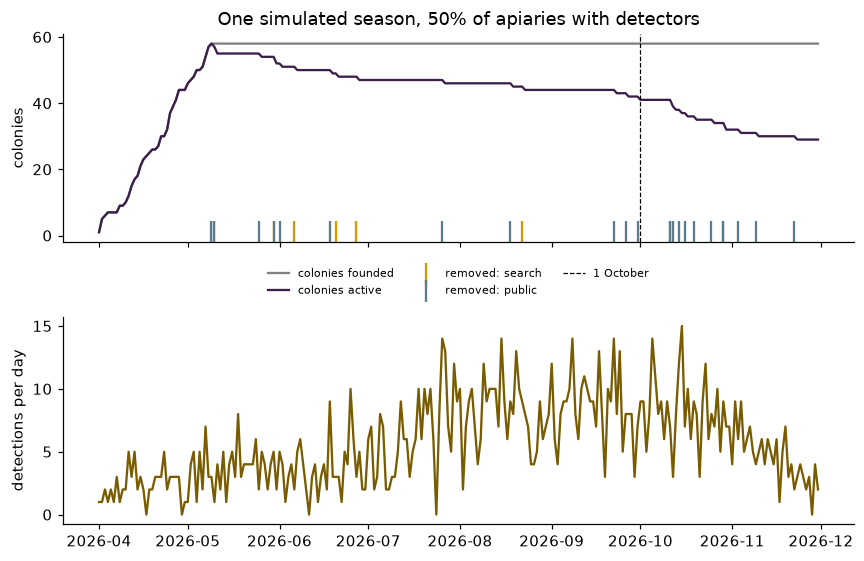

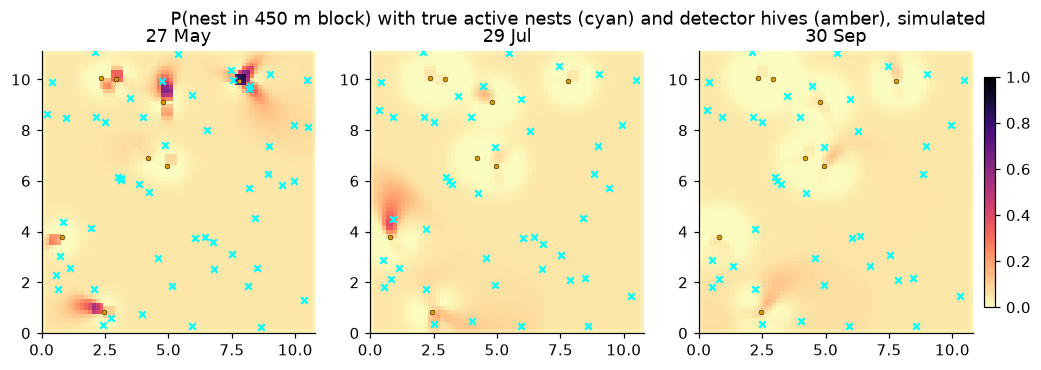

In [170]:
days = np.arange(P["season_days"])
founded = np.array([(COL.found.values <= d).sum() for d in days])
active = np.array([((COL.found.values <= d) & (SEASON["removed"] > d)).sum() for d in days])
fig, ax = plt.subplots(2, 1, figsize=(8, 5.2), sharex=True)
ax[0].plot(DATES, founded, color="grey", label="colonies founded")
ax[0].plot(DATES, active, color="#3b1f4a", label="colonies active")
for how, c in [("search", "#d99a00"), ("public", "#5b7c8d")]:
    r = SEASON["removed"][SEASON["removed_by"] == how]
    ax[0].scatter(DATES[0] + pd.to_timedelta(r - 1, "D"), np.full(r.size, 1), marker="|", s=200, color=c, label=f"removed: {how}")
ax[0].axvline(DATES[P["reproduction_day"]], ls="--", c="k", lw=0.8, label="1 October")
ax[0].set_ylabel("colonies"); ax[0].legend(fontsize=7, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.08), frameon=False)
ax[0].set_title("One simulated season, 50% of apiaries with detectors")
ax[1].plot(DATES, SEASON["counts_per_day"], color="#7a5c00"); ax[1].set_ylabel("detections per day")
plt.tight_layout(); plt.show()

fr = sorted(SEASON["frames"])
pick = [fr[len(fr) // 4], fr[len(fr) // 2], fr[3 * len(fr) // 4]]
fig, axs = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, d in zip(axs, pick):
    im = ax.imshow(SEASON["frames"][d].reshape(NY, NX), origin="lower", extent=[0, AREA_W / 1000, 0, AREA_H / 1000], cmap="magma_r", vmin=0, vmax=1)
    on = (COL.found.values <= d) & (SEASON["removed"] > d)
    x = np.where(d >= COL.reloc.values, COL.sx.values, COL.px.values)[on]
    y = np.where(d >= COL.reloc.values, COL.sy.values, COL.py.values)[on]
    ax.scatter(x / 1000, y / 1000, marker="x", c="cyan", s=18)
    ax.scatter(HX[DEFAULT_DETECTORS] / 1000, HY[DEFAULT_DETECTORS] / 1000, s=10, c="#d99a00", edgecolor="k", lw=0.3)
    ax.set_title(DATES[d].strftime("%d %b"))
fig.suptitle("P(nest in 450 m block) with true active nests (cyan) and detector hives (amber), simulated")
fig.colorbar(im, ax=axs, shrink=0.8, pad=0.01)
plt.show()

## 10. Scenario study: detector coverage

The same apiaries are simulated with 0%, 25%, 50% and 100% of them carrying detectors, each over `N_REPS`
independent seasons (new colonies each time). With no detectors, nests are only removed after public reports.
The key outcome is the number of colonies still active on 1 October, when new queens are produced.

In [171]:
N_REPS = 6
COVERAGES = [0.0, 0.25, 0.5, 1.0]
rows = []
t0 = time.time()
for rep in range(N_REPS):
    col_r = simulate_colonies(MASTER_SEED + 100 + rep)
    order = np.random.default_rng(MASTER_SEED + 200 + rep).permutation(NH)
    for cov in COVERAGES:
        det = np.zeros(NH, bool); det[order[:int(round(cov * NH))]] = True
        s = run_season(col_r, det, MASTER_SEED + 300 + rep)["summary"]
        rows.append(dict(rep=rep, coverage=cov, **s))
    COLONY_SITES.clear()
SCEN = pd.DataFrame(rows)
print(f"{len(SCEN)} seasons in {time.time() - t0:.0f} s")
summary = SCEN.groupby("coverage")[["colonies", "active_on_1_oct", "removed_search", "removed_public",
                                    "searches", "success_rate", "median_removal_day"]].mean().round(2)
summary

24 seasons in 34 s


,colonies,active_on_1_oct,removed_search,removed_public,searches,success_rate,median_removal_day
coverage,,,,,,,
0.00,60.67,45.00,0.00,26.83,0.0,NaN,163.58
0.25,60.67,42.50,3.00,26.00,36.0,0.09,141.75
0.50,60.67,41.17,4.33,25.50,36.5,0.12,132.75
1.00,60.67,38.83,7.67,24.00,52.5,0.15,127.50


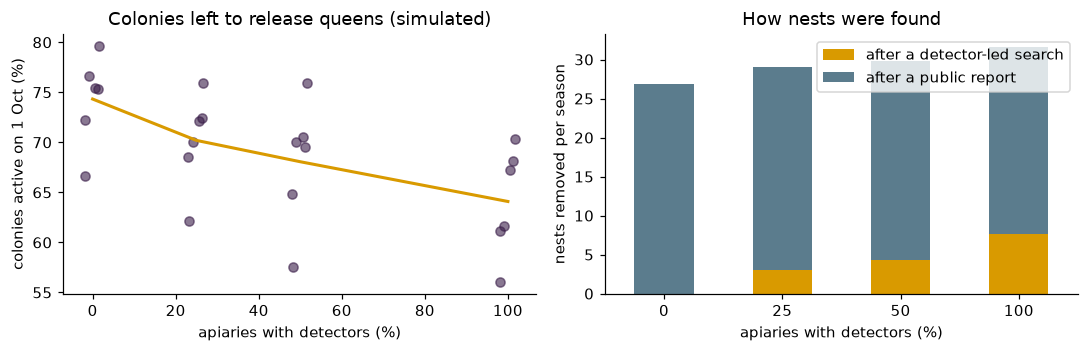

In [172]:
SCEN["share_active_1_oct"] = SCEN.active_on_1_oct / SCEN.colonies
fig, ax = plt.subplots(1, 2, figsize=(10, 3.3))
for cov in COVERAGES:
    v = SCEN[SCEN.coverage == cov]
    jitter = np.random.default_rng(0).uniform(-2, 2, len(v))
    ax[0].scatter(np.full(len(v), cov * 100) + jitter, v.share_active_1_oct * 100, color="#3b1f4a", alpha=0.6)
m = SCEN.groupby("coverage").share_active_1_oct.mean()
ax[0].plot(m.index * 100, m.values * 100, color="#d99a00", lw=2)
ax[0].set_xlabel("apiaries with detectors (%)"); ax[0].set_ylabel("colonies active on 1 Oct (%)")
ax[0].set_title("Colonies left to release queens (simulated)")
sr = SCEN.groupby("coverage")[["removed_search", "removed_public"]].mean()
sr.index = (sr.index * 100).astype(int)
sr.columns = ["after a detector-led search", "after a public report"]
sr.plot(kind="bar", stacked=True, ax=ax[1], color=["#d99a00", "#5b7c8d"], rot=0)
ax[1].set_xlabel("apiaries with detectors (%)"); ax[1].set_ylabel("nests removed per season"); ax[1].set_title("How nests were found")
plt.tight_layout(); plt.show()

## 11. Localisation accuracy of successful searches

For every search that found a nest in the default season, this is the distance between the targeted cell centre
and the nest. It indicates how large an area teams have to search on the ground.

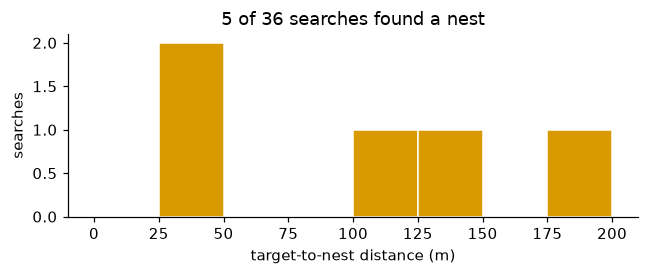

In [173]:
srch = SEASON["searches"]
if len(srch) and srch.success.any():
    fig, ax = plt.subplots(figsize=(6, 2.6))
    ax.hist(srch.error_m.dropna(), bins=np.arange(0, 225, 25), color="#d99a00", edgecolor="white")
    ax.set_xlabel("target-to-nest distance (m)"); ax.set_ylabel("searches")
    ax.set_title(f"{int(srch.success.sum())} of {len(srch)} searches found a nest")
    plt.tight_layout(); plt.show()
else:
    print("No successful searches in this season.")

if HISTORIC is not None:
    hx, hy = ll2xy(HISTORIC["lat"], HISTORIC["lon"])
    dmin = np.hypot(hx[:, None] - HX[None, :], hy[:, None] - HY[None, :]).min(1)
    print("historic removals: nearest-apiary distance (m) quantiles:", np.percentile(dmin, [10, 50, 90]).round())

## 12. Interactive timelapse map

The map below replays the season in your browser with the same model, ported to JavaScript so that it can
re-run as you edit it. It needs an internet connection for the basemap and the Leaflet library.

- **Play** or drag the timeline to move through the season (space bar and arrow keys work too).
- **Click a hive** to fit or remove a detector. The whole season is re-run with that configuration, including
  the searches it triggers.
- Tick **Click the map to add a removed nest**, then click where a nest was destroyed. It takes effect on the day
  shown; a true nest within 100 m is removed with it, and the model treats the point as a known source.
- **Undo all changes** restores the default detectors and removes your nests.

The probability layer is the model's estimate; the black-and-yellow dots are the simulated truth, which a real
deployment would not see. The page is also saved to `output/hornet_timelapse.html` for a full-window view.

In [174]:
def widget_payload(col, detectors, seed=MASTER_SEED):
    def fin(v):
        return None if not np.isfinite(v) else float(v)
    lat_sw, lon_sw = xy2ll(0, 0)
    lat_ne, lon_ne = xy2ll(NX * P["cell"], NY * P["cell"])
    pp = {k: (float(v) if isinstance(v, (int, float, np.floating, np.integer)) and not isinstance(v, bool) else v)
          for k, v in P.items() if not isinstance(v, (tuple, list))}
    return dict(
        seed=int(seed) % 2**31, P=pp, start_date=P["start_date"],
        geo=dict(lat0=P["lat0"], lon0=P["lon0"], latc=LATC, coslat=COSLAT, R=R_EARTH),
        grid=dict(nx=NX, ny=NY, south=float(lat_sw), west=float(lon_sw), north=float(lat_ne), east=float(lon_ne)),
        hives=[dict(x=float(h.x), y=float(h.y), lat=float(h.lat), lon=float(h.lon), colonies=int(h.colonies),
                    w=float(h.w), detector=bool(dd)) for h, dd in zip(HIVES.itertuples(), detectors)],
        colonies=[dict(px=float(c.px), py=float(c.py), sx=float(c.sx), sy=float(c.sy), found=int(c.found),
                       reloc=fin(c.reloc), switch=float(c.switch), amax=float(c.amax),
                       pub_pri=fin(c.pub_pri), pub_sec=fin(c.pub_sec)) for c in col.itertuples()],
        public=[dict(lat=float(r.lat), lon=float(r.lon), year=(int(r.year) if pd.notna(r.year) else None))
                for r in public.dropna(subset=["lat", "lon"]).itertuples()],
        historic=([dict(lat=float(r.lat), lon=float(r.lon), date=str(r.date)) for r in HISTORIC.itertuples()]
                  if HISTORIC is not None else []),
    )
PAYLOAD = widget_payload(COL, DEFAULT_DETECTORS)

In [175]:
WIDGET_CORE_JS = r'''
// Hornet nest simulator core: same model as the notebook, ported for the interactive map.
// Exposes createSim(D) where D is the payload written by the notebook.
function createSim(D) {
  const P = D.P, NB = P.n_bins, NX = D.grid.nx, NY = D.grid.ny, CELL = P.cell;
  const NCELL = NX * NY, NH = D.hives.length, NC = D.colonies.length, T = P.season_days;
  const TWO_PI = 2 * Math.PI;
  const CX = new Float64Array(NCELL), CY = new Float64Array(NCELL);
  for (let j = 0; j < NY; j++) for (let i = 0; i < NX; i++) { CX[j * NX + i] = (i + 0.5) * CELL; CY[j * NX + i] = (j + 0.5) * CELL; }
  const HX = D.hives.map(h => h.x), HY = D.hives.map(h => h.y), HW = D.hives.map(h => h.w);

  // ---------- random numbers: one stream per (day, a, b, tag) so edits only change what they touch
  function hash(a, b, c, d) {
    let h = (D.seed ^ 0x9e3779b9) >>> 0;
    for (const v of [a, b, c, d]) {
      h = Math.imul(h ^ ((v | 0) + 0x7f4a7c15), 0x85ebca6b) >>> 0;
      h = (h ^ (h >>> 13)) >>> 0; h = Math.imul(h, 0xc2b2ae35) >>> 0; h = (h ^ (h >>> 16)) >>> 0;
    }
    return h;
  }
  function stream(a, b, c, d) {
    let s = hash(a, b, c, d);
    return function () {
      s = (s + 0x6d2b79f5) >>> 0; let t = s;
      t = Math.imul(t ^ (t >>> 15), t | 1); t ^= t + Math.imul(t ^ (t >>> 7), t | 61);
      return ((t ^ (t >>> 14)) >>> 0) / 4294967296;
    };
  }
  function gauss(r) { let u = 0; while (u === 0) u = r(); return Math.sqrt(-2 * Math.log(u)) * Math.cos(TWO_PI * r()); }
  function poisson(r, lam) {
    if (lam <= 0) return 0;
    if (lam > 30) return Math.max(0, Math.round(lam + Math.sqrt(lam) * gauss(r)));
    const L = Math.exp(-lam); let k = 0, p = 1;
    do { k++; p *= r(); } while (p > L);
    return k - 1;
  }
  function binom(r, n, p) { let k = 0; for (let i = 0; i < n; i++) if (r() < p) k++; return k; }

  // ---------- model functions (mirror the notebook)
  const SQ2PI = Math.sqrt(2 * Math.PI);
  function lnpdf(x, m, s) { return Math.exp(-0.5 * ((x - m) / s) ** 2) / (s * SQ2PI); }
  function kraw(d) {
    d = Math.max(d, 1);
    const f = lnpdf(Math.log(d), Math.log(P.kernel_median), P.kernel_sigma) / d;
    return f / d * (1 - Math.exp(-((d / P.buffer_b) ** 2)));
  }
  let KNORM = 0; for (let d = 1; d <= 3000; d += (3000 - 1) / 2999) KNORM = Math.max(KNORM, kraw(d));
  const kernel = d => kraw(d) / KNORM;
  function activity(t) {
    const g = 1 / (1 + Math.exp(-P.act_k * (t - P.act_mid)));
    return t > P.act_end ? g * Math.exp(-(t - P.act_end) / P.act_decay) : g;
  }
  const BC = new Float64Array(NB); for (let b = 0; b < NB; b++) BC[b] = (b + 0.5) * TWO_PI / NB;
  function siteFactors(x, y, K, G, off) {
    // K: NH entries at K[off*NH + h]; G: NH*NB entries at G[(off*NH + h)*NB + b]
    let s = 0; const kw = new Float64Array(NH);
    for (let h = 0; h < NH; h++) { kw[h] = HW[h] * kernel(Math.hypot(x - HX[h], y - HY[h])); s += kw[h]; }
    for (let h = 0; h < NH; h++) {
      const dx = x - HX[h], dy = y - HY[h], d = Math.hypot(dx, dy);
      K[off * NH + h] = P.p_det * kw[h] / (P.beta_away + s);
      const phi = ((Math.atan2(dx, dy) % TWO_PI) + TWO_PI) % TWO_PI;
      const kap = P.kappa0 / (1 + d / P.kappa_d0);
      let mx = -Infinity; const base = (off * NH + h) * NB;
      for (let b = 0; b < NB; b++) { const v = kap * Math.cos(BC[b] - phi); G[base + b] = v; if (v > mx) mx = v; }
      let z = 0; for (let b = 0; b < NB; b++) { const e = Math.exp(G[base + b] - mx); G[base + b] = e; z += e; }
      for (let b = 0; b < NB; b++) G[base + b] /= z;
    }
  }
  const GK = new Float32Array(NCELL * NH), GG = new Float32Array(NCELL * NH * NB);
  for (let c = 0; c < NCELL; c++) siteFactors(CX[c], CY[c], GK, GG, c);
  // sparse neighbour lists: hives that a nest in cell c could plausibly visit
  const NBR = [];
  for (let c = 0; c < NCELL; c++) { const l = []; for (let h = 0; h < NH; h++) if (GK[c * NH + h] > 1e-4) l.push(h); NBR.push(Int32Array.from(l)); }
  const COLS = D.colonies;
  const CK = new Float32Array(NC * 2 * NH), CG = new Float32Array(NC * 2 * NH * NB);
  COLS.forEach((c, i) => { siteFactors(c.px, c.py, CK, CG, 2 * i); siteFactors(c.sx, c.sy, CK, CG, 2 * i + 1); });
  const reloc = COLS.map(c => (c.reloc === null ? Infinity : c.reloc));
  const pubPri = COLS.map(c => (c.pub_pri === null ? Infinity : c.pub_pri));
  const pubSec = COLS.map(c => (c.pub_sec === null ? Infinity : c.pub_sec));

  const QHH = P.q_HH, QFH = P.q_FH;
  const PH = P.p_homing * QHH + (1 - P.p_homing) * QFH;
  const PC = [PH, 1 - PH];
  const PI = [P.p_homing * P.pi_dir * QHH / PH, P.p_homing * P.pi_dir * (1 - QHH) / (1 - PH)];
  const CLUT = [QFH, 1 - QFH];

  // ---------- state
  const S = {
    detectors: Uint8Array.from(D.hives.map(h => (h.detector ? 1 : 0))),
    userRemovals: [],            // {x, y, day}
  };
  let sim = null;

  function siteOf(i, d) { return d >= reloc[i] ? 1 : 0; }
  function sitePos(i, d) { const c = COLS[i]; return siteOf(i, d) ? [c.sx, c.sy] : [c.px, c.py]; }

  function reset() {
    sim = {
      day: -1,
      counts: [],                 // per day Int32Array(NH*2*NB)
      bearings: [],               // per day: [h, bin] for class-H detections (for drawing)
      removed: new Float64Array(NC).fill(Infinity), removedBy: new Array(NC).fill(""),
      known: [],                  // {x, y, day, how, colony, K, G}
      searches: [], blocked: [], maps: new Map(),
    };
  }

  function addKnown(x, y, day, how, colony) {
    const K = new Float32Array(NH), G = new Float32Array(NH * NB);
    siteFactors(x, y, K, G, 0);
    sim.known.push({ x, y, day, how, colony, K, G });
  }
  function remove(i, day, how, at) {
    sim.removed[i] = day; sim.removedBy[i] = how;
    const [x, y] = at || sitePos(i, day - 1);
    addKnown(x, y, day, how, i);
  }

  function genSource(cnt, bear, r, lam, Gbase, Garr, h) {
    const n = poisson(r, lam); if (!n) return;
    const nh = binom(r, n, P.p_homing), nf = n - nh;
    const nd = binom(r, nh, P.pi_dir), nu = nh - nd;
    for (let k = 0; k < nd; k++) {
      const cls = r() < QHH ? 0 : 1;
      let u = r(), b = 0; for (; b < NB - 1; b++) { u -= Garr[Gbase + b]; if (u <= 0) break; }
      cnt[(h * 2 + cls) * NB + b]++; if (cls === 0) bear.push(h, b);
    }
    for (let k = 0; k < nu + nf; k++) {
      const cls = r() < (k < nu ? QHH : QFH) ? 0 : 1, b = Math.floor(r() * NB);
      cnt[(h * 2 + cls) * NB + b]++; if (cls === 0) bear.push(h, b);
    }
  }

  function stepDay(d) {
    const found = i => COLS[i].found <= d;
    // user removals entered for this day
    for (const u of S.userRemovals) if (u.day === d) {
      let best = -1, bd = 100;
      for (let i = 0; i < NC; i++) if (found(i) && sim.removed[i] > d) {
        const [x, y] = sitePos(i, d); const dist = Math.hypot(x - u.x, y - u.y);
        if (dist < bd) { bd = dist; best = i; }
      }
      if (best >= 0) remove(best, d, "you", [u.x, u.y]); else addKnown(u.x, u.y, d, "you", -1);
    }
    for (let i = 0; i < NC; i++) if (found(i) && sim.removed[i] > d) {
      const sec = d >= COLS[i].switch;
      if ((!sec && d >= pubPri[i]) || (sec && d >= pubSec[i])) remove(i, d, "public");
    }
    const cnt = new Int32Array(NH * 2 * NB), bear = [];
    const act = activity(d);
    for (let h = 0; h < NH; h++) {
      if (!S.detectors[h]) continue;
      for (let i = 0; i < NC; i++) {
        if (!(found(i) && sim.removed[i] > d)) continue;
        const s = 2 * i + siteOf(i, d), lam = COLS[i].amax * act * CK[s * NH + h];
        if (lam < 1e-4) continue;
        genSource(cnt, bear, stream(d, h, i, 1), lam, (s * NH + h) * NB, CG, h);
      }
      const r = stream(d, h, -1, 3), n = poisson(r, P.clutter_rate);
      for (let k = 0; k < n; k++) { const cls = r() < QFH ? 0 : 1, b = Math.floor(r() * NB); cnt[(h * 2 + cls) * NB + b]++; if (cls === 0) bear.push(h, b); }
    }
    sim.counts[d] = cnt; sim.bearings[d] = bear;
    const weekly = d >= P.search_start && (d - P.search_start) % P.search_every === 0;
    if (weekly && S.detectors.some(v => v)) {
      const res = infer(d); sim.maps.set(d, res);
      search(d, res.p3);
    }
    sim.day = d;
  }

  function windowCounts(d) {
    const lo = Math.max(0, d - P.window + 1), n = new Float64Array(NH * 2 * NB);
    for (let t = lo; t <= d; t++) { const c = sim.counts[t]; for (let k = 0; k < c.length; k++) n[k] += c[k]; }
    return { n, lo };
  }

  function aRef(t) { return P.act_max_median * Math.max(activity(t), 0.05); }

  function box3(z) {
    const out = new Float64Array(NCELL);
    for (let j = 0; j < NY; j++) for (let i = 0; i < NX; i++) {
      let s = 0;
      for (let dj = -1; dj <= 1; dj++) for (let di = -1; di <= 1; di++) {
        const jj = j + dj, ii = i + di;
        if (jj >= 0 && jj < NY && ii >= 0 && ii < NX) s += z[jj * NX + ii];
      }
      out[j * NX + i] = s;
    }
    return out;
  }

  function infer(d) {
    const W = Math.min(P.window, d + 1);
    const hs = []; for (let h = 0; h < NH; h++) if (S.detectors[h]) hs.push(h);
    const lam0 = P.nest_density * (CELL * CELL / 1e6) * 0.5;
    const lam = new Float64Array(NCELL);
    if (!hs.length) { lam.fill(lam0); return finish(lam); }
    const { n, lo } = windowCounts(d);
    const expo = new Float64Array(NCELL);
    for (let c = 0; c < NCELL; c++) { let s = 0; for (const h of hs) s += GK[c * NH + h]; expo[c] = W * s; }
    const kn = sim.known.filter(k => k.day > lo).map(k => ({ ...k, E: Math.min(P.window, k.day - lo) }));
    const hd = hs.filter(h => { for (let k = 0; k < 2 * NB; k++) if (n[h * 2 * NB + k] > 0) return true; return false; });
    const hasData = new Uint8Array(NH); for (const h of hd) hasData[h] = 1;
    let total = 0; for (let k = 0; k < n.length; k++) total += n[k];
    let es = 0; for (let c = 0; c < NCELL; c++) es += expo[c];
    const init = Math.max(total, 1) / (es + 1e-9);
    const mu = new Float64Array(NCELL); for (let c = 0; c < NCELL; c++) mu[c] = expo[c] > 1e-6 ? init : 0;
    const mus = new Float64Array(kn.length).fill(init);
    const GA = new Float64Array(NH * NB), sA = new Float64Array(NH), rdir = new Float64Array(NH * NB), rund = new Float64Array(NH);
    const cl = [P.clutter_rate * W * CLUT[0] / NB, P.clutter_rate * W * CLUT[1] / NB];
    for (let it = 0; it < P.em_iter; it++) {
      GA.fill(0); sA.fill(0);
      for (let c = 0; c < NCELL; c++) {
        const m = mu[c] * W; if (m <= 0) continue;
        for (const h of NBR[c]) {
          if (!hasData[h]) continue;
          const a = m * GK[c * NH + h];
          sA[h] += a; const gb = (c * NH + h) * NB, ob = h * NB;
          for (let b = 0; b < NB; b++) GA[ob + b] += a * GG[gb + b];
        }
      }
      kn.forEach((k, s) => {
        const m = mus[s] * k.E; if (m <= 0) return;
        for (const h of hd) { const a = m * k.K[h]; sA[h] += a; for (let b = 0; b < NB; b++) GA[h * NB + b] += a * k.G[h * NB + b]; }
      });
      rdir.fill(0); rund.fill(0);
      for (const h of hd) for (let cls = 0; cls < 2; cls++) for (let b = 0; b < NB; b++) {
        const v = n[(h * 2 + cls) * NB + b]; if (!v) continue;
        const pred = cl[cls] + PC[cls] * (PI[cls] * GA[h * NB + b] + (1 - PI[cls]) * sA[h] / NB);
        const ratio = v / Math.max(pred, 1e-12);
        rdir[h * NB + b] += PC[cls] * PI[cls] * ratio; rund[h] += PC[cls] * (1 - PI[cls]) / NB * ratio;
      }
      for (let c = 0; c < NCELL; c++) {
        if (expo[c] <= 1e-6) continue;
        let s = 0;
        for (const h of NBR[c]) {
          if (!hasData[h]) continue;
          const k = GK[c * NH + h];
          const gb = (c * NH + h) * NB, ob = h * NB; let dot = 0;
          for (let b = 0; b < NB; b++) dot += GG[gb + b] * rdir[ob + b];
          s += k * (dot + rund[h]);
        }
        mu[c] *= W * s / expo[c];
      }
      kn.forEach((k, s) => {
        let e = 0, bk = 0;
        for (const h of hs) e += k.K[h];
        for (const h of hd) { let dot = 0; for (let b = 0; b < NB; b++) dot += k.G[h * NB + b] * rdir[h * NB + b]; bk += k.K[h] * (dot + rund[h]); }
        mus[s] = e > 1e-9 ? mus[s] * bk / e : 0;
      });
    }
    const ar = aRef(d);
    for (let c = 0; c < NCELL; c++) lam[c] = mu[c] / ar + lam0 * Math.exp(-ar * expo[c]);
    return finish(lam);
  }
  function finish(lam) {
    const b = box3(lam), p3 = new Float32Array(NCELL);
    for (let c = 0; c < NCELL; c++) p3[c] = 1 - Math.exp(-b[c]);
    return { p3 };
  }

  function search(d, p3in) {
    const p3 = Float64Array.from(p3in);
    sim.blocked = sim.blocked.filter(b => b[2] > d);
    for (const [bx, by] of sim.blocked) for (let c = 0; c < NCELL; c++) if (Math.hypot(CX[c] - bx, CY[c] - by) < P.search_radius) p3[c] = 0;
    const order = Array.from(p3.keys()).sort((a, b) => p3[b] - p3[a]);
    const chosen = [];
    for (const c of order) {
      if (p3[c] < P.p_thresh || chosen.length >= P.teams) break;
      if (chosen.every(o => Math.hypot(CX[c] - CX[o], CY[c] - CY[o]) >= P.nms_radius)) chosen.push(c);
    }
    for (const c of chosen) {
      let best = -1, bd = 200.0001;
      for (let i = 0; i < NC; i++) if (COLS[i].found <= d && sim.removed[i] > d) {
        const [x, y] = sitePos(i, d), dist = Math.hypot(x - CX[c], y - CY[c]);
        if (dist < bd) { bd = dist; best = i; }
      }
      let ok = false;
      if (best >= 0) {
        const pf = d >= COLS[best].switch ? P.p_find_secondary : P.p_find_primary;
        if (stream(d, c, 0, 2)() < pf) { remove(best, d + 1, "search"); ok = true; }
      }
      sim.searches.push({ day: d, x: CX[c], y: CY[c], p: p3in[c], success: ok });
      if (!ok) sim.blocked.push([CX[c], CY[c], d + 14]);
    }
  }

  function runTo(d) { d = Math.min(d, T - 1); while (sim.day < d) stepDay(sim.day + 1); }
  function mapFor(d) {
    runTo(d);
    if (!sim.maps.has(d)) sim.maps.set(d, infer(d));
    return sim.maps.get(d).p3;
  }
  function stateAt(d) {
    runTo(d);
    const active = [], removed = [];
    for (let i = 0; i < NC; i++) {
      if (COLS[i].found > d) continue;
      if (sim.removed[i] > d) { const [x, y] = sitePos(i, d); active.push({ i, x, y, secondary: d >= reloc[i] }); }
    }
    for (const k of sim.known) if (k.day <= d) removed.push(k);
    const lo = Math.max(0, d - P.window + 1); let win = 0;
    for (let t = lo; t <= d; t++) { const c = sim.counts[t]; for (let k = 0; k < c.length; k++) win += c[k]; }
    const repro = P.reproduction_day;
    let activeRepro = null;
    if (d >= repro) { activeRepro = 0; for (let i = 0; i < NC; i++) if (COLS[i].found <= repro && sim.removed[i] > repro) activeRepro++; }
    return { active, removed, bearings: sim.bearings[d] || [], searches: sim.searches.filter(s => s.day === d),
             windowDetections: win, activeRepro, founded: COLS.filter(c => c.found <= d).length };
  }

  reset();
  return {
    S, reset, runTo, mapFor, stateAt, NX, NY, NCELL, CX, CY, T, NB,
    toggleDetector(h) { S.detectors[h] = S.detectors[h] ? 0 : 1; reset(); },
    addRemoval(x, y, day) { S.userRemovals.push({ x, y, day }); reset(); },
    clearEdits() { S.detectors = Uint8Array.from(D.hives.map(h => (h.detector ? 1 : 0))); S.userRemovals = []; reset(); },
    summary() {
      const by = { search: 0, public: 0, you: 0 };
      sim.removedBy.forEach(b => { if (b) by[b]++; });
      return { removedBy: by, searches: sim.searches.length, success: sim.searches.filter(s => s.success).length };
    },
  };
}
if (typeof module !== "undefined") module.exports = { createSim };
'''

In [176]:
WIDGET_HTML = r'''
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1, viewport-fit=cover">
<title>Hornet nest finder: simulated season</title>
<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/leaflet/1.9.4/leaflet.min.css">
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Atkinson+Hyperlegible:wght@400;700&display=swap" rel="stylesheet">
<style>
  :root {
    --ink: #1e2b24; --muted: #5d6a62; --line: #d9ddd6; --paper: #ffffff;
    --honey: #e0a100; --honey-dark: #8a6200; --plum: #4b1d6b;
    --found: #1f7a4d; --public: #5b6b78; --you: #c2185b;
    --font: "Atkinson Hyperlegible", "Segoe UI", system-ui, -apple-system, sans-serif;
  }
  * { box-sizing: border-box; }
  html, body { margin: 0; height: 100%; font-family: var(--font); color: var(--ink); background: #eef0ec; }
  #app { position: relative; height: 100%; min-height: 560px; }
  #map { position: absolute; inset: 0; }
  .leaflet-container { font-family: var(--font); background: #e8ebe6; }
  .drawer-wrap {
    position: absolute; top: 12px; left: 0; z-index: 500;
    display: flex; align-items: flex-start;
    transition: transform .25s ease;
  }
  .panel {
    margin-left: 12px; width: 290px; max-height: calc(100vh - 110px);
    overflow-y: auto; background: var(--paper); border: 1px solid var(--line); border-radius: 10px;
    padding: 14px 16px 12px; box-shadow: 0 2px 10px rgba(30, 43, 36, .12);
  }
  #drawer-toggle {
    margin: 4px 0 0 4px; flex-shrink: 0; width: 26px; height: 26px;
    display: flex; align-items: center; justify-content: center;
    background: var(--paper); border: 1px solid var(--line); border-radius: 6px;
    cursor: pointer; font-size: 14px; color: var(--muted);
    box-shadow: 0 2px 6px rgba(30,43,36,.1);
  }
  #app.drawer-closed .drawer-wrap { transform: translateX(-302px); }
  .date { font-size: 30px; font-weight: 700; line-height: 1.05; letter-spacing: -0.01em; }
  .sub { color: var(--muted); font-size: 13px; margin-top: 4px; }
  .stats { display: grid; grid-template-columns: 1fr auto; gap: 3px 10px; margin: 12px 0 10px; font-size: 14px; }
  .stats dd { margin: 0; font-weight: 700; font-variant-numeric: tabular-nums; text-align: right; }
  .stats dt { color: var(--muted); }
  h2 { font-size: 13px; font-weight: 700; margin: 12px 0 6px; color: var(--ink); }
  .legend { display: grid; grid-template-columns: 22px 1fr; gap: 5px 8px; align-items: center; font-size: 13px; }
  .ramp { height: 10px; border-radius: 3px; margin: 2px 0 2px;
          background: linear-gradient(90deg, rgba(196,170,228,.45), #9664c4 30%, #602c8c 60%, #3e145f 85%, #2a0b40); }
  .ramp-labels { display: flex; justify-content: space-between; font-size: 11px; color: var(--muted); }
  .sym { width: 16px; height: 16px; display: inline-block; justify-self: center; }
  label.opt { display: flex; gap: 8px; align-items: center; font-size: 14px; margin: 5px 0; cursor: pointer; }
  label.opt input { width: 16px; height: 16px; accent-color: var(--plum); }
  .mode { margin-top: 10px; padding: 8px 10px; border-radius: 8px; background: #f6f2fa; font-size: 13px; color: var(--plum); }
  .note { font-size: 12px; color: var(--muted); margin-top: 8px; line-height: 1.4; }
  button { font-family: var(--font); }
  .btn { border: 1px solid var(--line); background: #fff; color: var(--ink); border-radius: 8px; padding: 6px 10px; font-size: 13px; cursor: pointer; }
  .btn:hover { border-color: var(--muted); }
  :focus-visible { outline: 3px solid var(--honey); outline-offset: 2px; }
  .timeline {
    position: absolute; left: 12px; right: 12px; bottom: 12px; z-index: 500; background: var(--paper);
    border: 1px solid var(--line); border-radius: 10px; padding: 10px 14px; display: flex; gap: 14px; align-items: center;
    box-shadow: 0 2px 10px rgba(30, 43, 36, .12);
  }
  .play { width: 40px; height: 40px; border-radius: 50%; border: 0; background: var(--ink); color: #fff; font-size: 16px; cursor: pointer; flex: none; }
  .track { flex: 1; min-width: 120px; }
  .track input { width: 100%; accent-color: var(--plum); }
  .months { display: flex; justify-content: space-between; font-size: 11px; color: var(--muted); margin-top: 2px; }
  select { font-family: var(--font); font-size: 13px; border: 1px solid var(--line); border-radius: 6px; padding: 4px; }
  .busy { position: absolute; top: 12px; left: 50%; transform: translateX(-50%); z-index: 600; background: var(--ink); color: #fff; font-size: 13px;
          padding: 8px 12px; border-radius: 8px; display: none; }
  .x-mark { font-weight: 700; font-size: 18px; line-height: 16px; text-align: center; text-shadow: 0 0 2px #fff, 0 0 2px #fff; }
  .crosshair .leaflet-container, .crosshair #map { cursor: crosshair !important; }
  @media (max-width: 640px) {
    .panel { width: calc(100vw - 60px); max-height: 42%; }
    .date { font-size: 24px; }
    .timeline { flex-wrap: wrap; }
  }
  @media (prefers-reduced-motion: reduce) { * { transition: none !important; } }

</style>
</head>
<body>
<div id="app">
  <div id="map" aria-label="Map of the study area"></div>
  <div class="drawer-wrap" id="drawer">
  <section class="panel" aria-label="Season status and map key">
    <div class="date" id="date">1 April</div>
    <div class="sub" id="sub">Simulated season, Alkmaar region</div>
    <dl class="stats">
      <dt>Active nests (simulated truth)</dt><dd id="s-active">0</dd>
      <dt>Removed after a detector-led search</dt><dd id="s-search">0</dd>
      <dt>Removed after a public report</dt><dd id="s-public">0</dd>
      <dt>Removed by you</dt><dd id="s-you">0</dd>
      <dt>Detections, last 14 days</dt><dd id="s-det">0</dd>
      <dt>Hives with detectors</dt><dd id="s-hives">0</dd>
      <dt>Still active on 1 October</dt><dd id="s-repro">–</dd>
    </dl>
    <h2>Probability of a nest within the 450 m block</h2>
    <div class="ramp" role="img" aria-label="Colour ramp from low to high probability"></div>
    <div class="ramp-labels"><span>0.1</span><span>0.5</span><span>1</span></div>
    <h2>On the map</h2>
    <div class="legend">
      <svg class="sym" viewBox="0 0 16 16"><circle cx="8" cy="8" r="6" fill="#e0a100" stroke="#1e2b24" stroke-width="2"/></svg><span>Hive with detector (click to remove it)</span>
      <svg class="sym" viewBox="0 0 16 16"><circle cx="8" cy="8" r="6" fill="#fff" stroke="#8a6200" stroke-width="2"/></svg><span>Hive without detector (click to add one)</span>
      <svg class="sym" viewBox="0 0 16 16"><circle cx="8" cy="8" r="4" fill="#111" stroke="#f2c200" stroke-width="2"/></svg><span>True active nest</span>
      <span class="sym x-mark" style="color:var(--found)">×</span><span>Removed after a search</span>
      <span class="sym x-mark" style="color:var(--public)">×</span><span>Removed after a public report</span>
      <span class="sym x-mark" style="color:var(--you)">×</span><span>Removed by you</span>
      <svg class="sym" viewBox="0 0 16 16"><circle cx="8" cy="8" r="6" fill="none" stroke="#1e2b24" stroke-dasharray="2 2"/></svg><span>Search today</span>
    </div>
    <h2>Show</h2>
    <label class="opt"><input type="checkbox" id="o-truth" checked> True nests</label>
    <label class="opt"><input type="checkbox" id="o-bear" checked> Today's homing-flight bearings</label>
    <label class="opt"><input type="checkbox" id="o-public"> Public records (GBIF, real)</label>
    <label class="opt"><input type="checkbox" id="o-add"> Click the map to add a removed nest</label>
    <div class="mode" id="mode" hidden>Click where a nest was destroyed. It is removed today, and any true nest within 100 m dies with it.</div>
    <div style="display:flex; gap:8px; margin-top:10px">
      <button class="btn" id="reset">Undo all changes</button>
    </div>
    <p class="note">Detector changes apply to the whole season, so the season is re-run from 1 April. Removed nests you add apply from the day shown. Nests, hornets and habitat are simulated; the basemap and public records are real.</p>
  </section>
  <button id="drawer-toggle" aria-label="Toggle panel" title="Toggle panel">&#8249;</button>
</div>
  <div class="busy" id="busy" role="status" aria-live="polite">Simulating up to the selected day…</div>
  <div class="timeline">
    <button class="play" id="play" aria-label="Play">▶</button>
    <div class="track">
      <input type="range" id="day" min="0" max="243" value="0" aria-label="Day of the season">
      <div class="months" id="months"></div>
    </div>
    <label style="font-size:13px; color:var(--muted)">Speed
      <select id="speed"><option value="1">1 day</option><option value="3" selected>3 days</option><option value="7">1 week</option></select>
    </label>
  </div>
</div>
<script src="https://cdnjs.cloudflare.com/ajax/libs/leaflet/1.9.4/leaflet.min.js"></script>
<script>
/*__CORE__*/
</script>
<script>
const D = /*__PAYLOAD__*/;
(function () {
  const sim = createSim(D);
  const P = D.P, G = D.grid, geo = D.geo, NB = P.n_bins;
  const start = new Date(D.start_date + "T00:00:00");
  const fmt = new Intl.DateTimeFormat("en-GB", { day: "numeric", month: "long" });
  const dayDate = d => new Date(start.getTime() + d * 86400000);
  const xy2ll = (x, y) => [geo.lat0 + (y / geo.R) * 180 / Math.PI, geo.lon0 + (x / (geo.R * geo.coslat)) * 180 / Math.PI];
  const ll2xy = (lat, lon) => [geo.R * geo.coslat * (lon - geo.lon0) * Math.PI / 180, geo.R * (lat - geo.lat0) * Math.PI / 180];

  const map = L.map("map", { preferCanvas: true, zoomControl: false, attributionControl: true });
  L.control.zoom({ position: "topright" }).addTo(map);
  L.tileLayer("https://service.pdok.nl/brt/achtergrondkaart/wmts/v2_0/grijs/EPSG:3857/{z}/{x}/{y}.png", {
    attribution: 'Kaartgegevens &copy; <a href="https://www.kadaster.nl">Kadaster</a>',
    maxZoom: 19,
  }).addTo(map);
  const bounds = [[G.south, G.west], [G.north, G.east]];
  map.fitBounds(bounds, { paddingTopLeft: [300, 10], paddingBottomRight: [10, 80] });
  L.rectangle(bounds, { color: "#1e2b24", weight: 1, fill: false, dashArray: "4 4", interactive: false }).addTo(map);

  const canvas = document.createElement("canvas"); canvas.width = sim.NX; canvas.height = sim.NY;
  const ctx = canvas.getContext("2d"), img = ctx.createImageData(sim.NX, sim.NY);
  const overlay = L.imageOverlay(canvas.toDataURL(), bounds, { opacity: 1, interactive: false }).addTo(map);
  const stops = [[0.06, [205, 184, 230, 0]], [0.12, [196, 170, 228, 95]], [0.3, [150, 100, 196, 165]], [0.55, [96, 44, 140, 205]], [0.8, [62, 20, 95, 225]], [1.0, [42, 11, 64, 235]]];
  function colour(p) {
    if (p <= stops[0][0]) return stops[0][1];
    for (let k = 1; k < stops.length; k++) if (p <= stops[k][0]) {
      const [p0, c0] = stops[k - 1], [p1, c1] = stops[k], t = (p - p0) / (p1 - p0);
      return c0.map((v, i) => v + t * (c1[i] - v));
    }
    return stops[stops.length - 1][1];
  }

  const layers = {
    bearings: L.layerGroup().addTo(map), searches: L.layerGroup().addTo(map), removed: L.layerGroup().addTo(map),
    truth: L.layerGroup().addTo(map), public: L.layerGroup(), historic: L.layerGroup().addTo(map), hives: L.layerGroup().addTo(map),
  };
  D.public.forEach(r => L.marker([r.lat, r.lon], { icon: L.divIcon({ className: "", html: '<div style="width:6px;height:6px;background:#5b6b78;opacity:0.7;transform:rotate(45deg);margin:-3px 0 0 -3px"></div>', iconSize: [1, 1], iconAnchor: [0, 0] }), interactive: true })
    .bindTooltip(`Public record${r.year ? ", " + r.year : ""} (GBIF; Dutch records are 5×5 km squares)`).addTo(layers.public));
  D.historic.forEach(r => L.marker([r.lat, r.lon], { icon: L.divIcon({ className: "x-mark", html: "×", iconSize: [16, 16] }), opacity: 0.45 })
    .bindTooltip(`Historic removal ${r.date} (your file)`).addTo(layers.historic));

  const hiveMarkers = D.hives.map((h, i) => {
    const m = L.circleMarker([h.lat, h.lon], { radius: 7, weight: 2.5, bubblingMouseEvents: false });
    m.on("click", e => { L.DomEvent.stop(e); sim.toggleDetector(i); styleHives(); rerun(); });
    m.on("keypress", e => { if (e.originalEvent.key === "Enter") { sim.toggleDetector(i); styleHives(); rerun(); } });
    m.addTo(layers.hives); return m;
  });
  function styleHives() {
    let n = 0;
    hiveMarkers.forEach((m, i) => {
      const on = !!sim.S.detectors[i]; n += on;
      m.setStyle(on ? { color: "#1e2b24", fillColor: "#e0a100", fillOpacity: 1, dashArray: null }
                    : { color: "#8a6200", fillColor: "#ffffff", fillOpacity: 1, dashArray: null });
      m.unbindTooltip().bindTooltip(`Apiary, ${D.hives[i].colonies} colonies: ${on ? "detector fitted" : "no detector"}. Click to ${on ? "remove" : "fit"} a detector.`);
    });
    document.getElementById("s-hives").textContent = `${n} of ${D.hives.length}`;
  }

  const el = id => document.getElementById(id);
  const slider = el("day"), playBtn = el("play"), busy = el("busy");
  slider.max = sim.T - 1;
  const months = el("months"); months.innerHTML = "";
  for (let d = 0; d < sim.T; d++) { const dt = dayDate(d); if (dt.getDate() === 1) { const s = document.createElement("span"); s.textContent = dt.toLocaleString("en-GB", { month: "short" }); months.appendChild(s); } }

  let current = 0, playing = false, timer = null, job = 0;

  function draw(d) {
    const p3 = sim.mapFor(d), st = sim.stateAt(d);
    for (let j = 0; j < sim.NY; j++) for (let i = 0; i < sim.NX; i++) {
      const c = colour(p3[j * sim.NX + i]), o = ((sim.NY - 1 - j) * sim.NX + i) * 4;
      img.data[o] = c[0]; img.data[o + 1] = c[1]; img.data[o + 2] = c[2]; img.data[o + 3] = c[3];
    }
    ctx.putImageData(img, 0, 0); overlay.setUrl(canvas.toDataURL());

    layers.truth.clearLayers();
    if (el("o-truth").checked) st.active.forEach(a => L.circleMarker(xy2ll(a.x, a.y), { radius: 4, color: "#f2c200", weight: 2, fillColor: "#111", fillOpacity: 1, interactive: true })
      .bindTooltip(`True ${a.secondary ? "secondary" : "primary"} nest (simulated)`).addTo(layers.truth));
    layers.removed.clearLayers();
    const col = { search: "var(--found)", public: "var(--public)", you: "var(--you)" };
    const label = { search: "a detector-led search", public: "a public report", you: "you" };
    st.removed.forEach(k => L.marker(xy2ll(k.x, k.y), { icon: L.divIcon({ className: "x-mark", html: `<span style="color:${col[k.how]}">×</span>`, iconSize: [16, 16] }), keyboard: false })
      .bindTooltip(`Removed ${fmt.format(dayDate(k.day))} after ${label[k.how]}${k.colony < 0 ? " (no true nest within 100 m)" : ""}`).addTo(layers.removed));
    layers.bearings.clearLayers();
    if (el("o-bear").checked) {
      const b = st.bearings, lim = Math.min(b.length, 600);
      for (let k = 0; k < lim; k += 2) {
        const h = D.hives[b[k]], ang = (b[k + 1] + 0.5) * 2 * Math.PI / NB;
        L.polyline([[h.lat, h.lon], xy2ll(h.x + 400 * Math.sin(ang), h.y + 400 * Math.cos(ang))], { color: "#b07d00", weight: 1.5, opacity: 0.45, interactive: false }).addTo(layers.bearings);
      }
    }
    layers.searches.clearLayers();
    st.searches.forEach(s => L.circle(xy2ll(s.x, s.y), { radius: 200, color: s.success ? "#1f7a4d" : "#1e2b24", weight: 1.5, dashArray: "4 4", fill: false })
      .bindTooltip(`Search, P = ${s.p.toFixed(2)}: ${s.success ? "nest found" : "nothing found"}`).addTo(layers.searches));

    el("date").textContent = fmt.format(dayDate(d));
    el("sub").textContent = `Day ${d + 1} of ${sim.T}, ${st.founded} colonies founded so far (simulated)`;
    el("s-active").textContent = st.active.length;
    const by = { search: 0, public: 0, you: 0 }; st.removed.forEach(k => by[k.how]++);
    el("s-search").textContent = by.search; el("s-public").textContent = by.public; el("s-you").textContent = by.you;
    el("s-det").textContent = st.windowDetections;
    el("s-repro").textContent = st.activeRepro === null ? "–" : st.activeRepro;
    slider.value = d;
  }

  // advance the simulation in small chunks so the page stays responsive
  function goTo(d, then) {
    const my = ++job;
    let step = 0;
    function run() {
      if (my !== job) return;
      const t0 = performance.now();
      while (step <= d && performance.now() - t0 < 35) { sim.runTo(step); step++; }
      if (step <= d) { busy.style.display = "block"; requestAnimationFrame(run); }
      else { busy.style.display = "none"; current = d; draw(d); if (then) then(); }
    }
    run();
  }
  function rerun() { goTo(current); }

  slider.addEventListener("input", () => { stop(); goTo(+slider.value); });
  function stop() { playing = false; playBtn.textContent = "▶"; playBtn.setAttribute("aria-label", "Play"); clearTimeout(timer); }
  function tick() {
    if (!playing) return;
    const next = Math.min(sim.T - 1, current + +el("speed").value);
    goTo(next, () => { if (next >= sim.T - 1) stop(); else timer = setTimeout(tick, 220); });
  }
  playBtn.addEventListener("click", () => {
    if (playing) { stop(); return; }
    if (current >= sim.T - 1) current = 0;
    playing = true; playBtn.textContent = "❚❚"; playBtn.setAttribute("aria-label", "Pause"); tick();
  });
  document.addEventListener("keydown", e => {
    if (e.target.tagName === "INPUT" || e.target.tagName === "SELECT") return;
    if (e.key === " ") { e.preventDefault(); playBtn.click(); }
    if (e.key === "ArrowRight") { stop(); goTo(Math.min(sim.T - 1, current + 1)); }
    if (e.key === "ArrowLeft") { stop(); goTo(Math.max(0, current - 1)); }
  });
  ["o-truth", "o-bear"].forEach(id => el(id).addEventListener("change", () => draw(current)));
  el("o-public").addEventListener("change", e => e.target.checked ? layers.public.addTo(map) : layers.public.remove());
  el("o-add").addEventListener("change", e => { el("mode").hidden = !e.target.checked; document.getElementById("app").classList.toggle("crosshair", e.target.checked); });
  map.on("click", e => {
    if (!el("o-add").checked) return;
    const [x, y] = ll2xy(e.latlng.lat, e.latlng.lng);
    sim.addRemoval(x, y, current); rerun();
  });
  el("reset").addEventListener("click", () => { stop(); sim.clearEdits(); styleHives(); rerun(); });

  styleHives();
  goTo(0);
})();

  document.getElementById("drawer-toggle").addEventListener("click", () => {
    const closed = document.getElementById("app").classList.toggle("drawer-closed");
    document.getElementById("drawer-toggle").textContent = closed ? "›" : "‹";
  });
</script>
</body>
</html>
'''

In [177]:
from IPython.display import HTML, display

def render_widget(payload, path=OUT_DIR / "hornet_timelapse.html", height=760):
    doc = WIDGET_HTML.replace("/*__CORE__*/", WIDGET_CORE_JS).replace("/*__PAYLOAD__*/", json.dumps(payload))
    path.write_text(doc, encoding="utf-8")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        display(HTML(f'<iframe srcdoc="{html.escape(doc, quote=True)}" style="width:100%;height:{height}px;'
                         f'border:1px solid #d9ddd6;border-radius:8px"></iframe>'))
    print(f"Saved to {path.resolve()}")

render_widget(PAYLOAD)

Saved to /Users/sebas/_Act/hoornaar-radar/docs/hornet_timelapse.html


## 13. What this study does and does not show

- **Coverage is the main lever.** With hives about 1 km apart, many nests are more than 800 m from any detector
  and stay invisible however good the inference is. The scenario study shows how the share of colonies left on
  1 October falls as coverage grows; temporary detectors at bait stations (documentation Section 7.4) are the
  cheap way to fill gaps.
- **Parameters marked as assumptions drive the absolute numbers.** Activity levels, the share of directed homing
  departures, detector hit rate and search success are guesses. Replace them with values fitted to confirmed
  nests (documentation Section 6) before using the numbers for decisions.
- **The habitat is synthetic.** For real use, rasterise BGT/BAG (buildings, trees) and AHN canopy height from
  PDOK onto the grid and use them as `BUILT` and `TREES`.
- **The inference is a fast approximation.** Windowed EM gives a usable map in milliseconds but does not give
  calibrated posterior probabilities; a Dirichlet-process or PHD-filter implementation (documentation Section 5)
  is the next step, and simulation-based calibration (Talts et al. 2018) should be run on it.
- **Real data hooks.** Drop `hives.csv`, `removed_nests.csv` or an NDFF export into `data/` and re-run; the
  notebook switches from simulated to real inputs where it can.